In [72]:
import numpy as np
import time
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

# ============================================================
# Gaussian Reservoir Implementation
# Same as reservoir.py but uses random Gaussian network
# ============================================================

def lorenz_euler(n_steps, dt=0.01, sigma=10.0, rho=28.0, beta=8/3, state0=None):
    """Generate Lorenz system data using Euler integration."""
    data = np.empty((n_steps, 3))
    state = np.array([1.0, 1.0, 1.0]) if state0 is None else np.array(state0, dtype=float)

    for i in range(n_steps):
        x, y, z = state
        state = state + dt * np.array([
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z,
        ])
        data[i] = state

    return data, state


def setup_gaussian_reservoir(
    N=463,          # Number of nodes (same as human connectome)
    J=1.5,
    lambda_reg=3e-6,
    t_thermalization=30,
    t_training=2000,
    sigma=10.0,
    rho=28.0,
    beta=8 / 3,
    dt=0.01,
    input_scale=1.5,
    seed=42,
    alpha=0.3,
):
    """
    Setup reservoir with random Gaussian weights instead of human connectome.
    """
    # -------------------------
    # Generate Gaussian reservoir matrix
    # -------------------------
    rng = np.random.default_rng(seed)
    
    # Random Gaussian matrix (dense, like standard ESN)
    # Use sqrt(N) for proper scaling - gives spectral radius ~1
    W_gaussian = rng.normal(size=(N, N)) / np.sqrt(N)
    
    # For non-symmetric matrices, use Schur decomposition for accurate spectral radius
    # Or use the more stable way: power iteration or simple eigenvalue computation
    # For symmetric-like random matrices, eigvals works but we need to be careful
    eigvals = np.linalg.eigvals(W_gaussian)
    rho_W = np.max(np.abs(eigvals))
    
    if rho_W == 0:
        raise ValueError("Gaussian matrix has zero spectral radius")
    
    # Scale to spectral radius J
    W = (J / rho_W) * W_gaussian
    
    # Verify the actual spectral radius after scaling
    actual_sr = np.max(np.abs(np.linalg.eigvals(W)))
    print(f"Gaussian reservoir: N={N}, target SR={J}, actual SR={actual_sr:.4f}")

    # -------------------------
    # Time step calculations
    # -------------------------
    washout_steps = round(t_thermalization / dt)
    train_steps = round(t_training / dt)
    total_steps = washout_steps + train_steps

    # -------------------------
    # Generate Lorenz training data
    # -------------------------
    lorenz_full, lorenz_last_state = lorenz_euler(
        total_steps, dt=dt, sigma=sigma, rho=rho, beta=beta
    )

    # Normalize input
    u_mean = lorenz_full.mean(axis=0)
    u_std = lorenz_full.std(axis=0)
    u_std[u_std == 0] = 1.0
    lorenz_full_norm = (lorenz_full - u_mean) / u_std
    u_tr = lorenz_full_norm[washout_steps:]

    # -------------------------
    # Input weight matrix
    # -------------------------
    W_in = input_scale * rng.normal(size=(N, 3))

    # -------------------------
    # Thermalization (washout)
    # -------------------------
    r = np.zeros(N)
    for t in range(washout_steps):
        r = (1-alpha) * r + alpha * np.tanh(W @ r + W_in @ lorenz_full_norm[t])

    # -------------------------
    # Training: collect reservoir states
    # -------------------------
    R_train = np.empty((train_steps, N))
    for t in range(train_steps):
        r = (1-alpha) * r + alpha * np.tanh(W @ r + W_in @ u_tr[t])
        R_train[t] = r

    # -------------------------
    # Train output weights (readout)
    # -------------------------
    RtR = R_train[:-1].T @ R_train[:-1]
    RtU = R_train[:-1].T @ u_tr[1:]
    W_out = np.linalg.solve(RtR + lambda_reg * np.eye(N), RtU)
    
    return W, W_in, W_out, r, u_tr, u_mean, u_std, lorenz_last_state


def run_simulation(W, W_in, W_out, r_last, u_mean, u_std, n_steps=200, alpha=0.3):
    """Run autonomous prediction after training."""
    N = W.shape[0]
    R = np.empty((n_steps, N))
    Y_norm = np.empty((n_steps, 3))
    Y = np.empty((n_steps, 3))

    r = r_last.copy()

    for t in range(n_steps):
        u_hat_norm = r @ W_out          # predicted normalized (x,y,z)
        u_hat = u_hat_norm * u_std + u_mean
        Y_norm[t] = u_hat_norm
        Y[t] = u_hat
        # feedback must be normalized
        r = (1-alpha) * r + alpha * np.tanh(W @ r + W_in @ u_hat_norm)
        R[t] = r

    return R, Y_norm, Y


def run_gaussian_reservoir_workflow(
    N,
    J,
    lambda_reg,
    t_thermalization,
    t_training,
    t_prediction,
    sigma,
    rho,
    beta,
    dt,
    input_scale,
    seed,
    alpha=0.3
):
    """Complete workflow for Gaussian reservoir."""
    # -------------------------
    # derived step counts
    # -------------------------
    washout_steps = round(t_thermalization / dt)
    train_steps = round(t_training / dt)
    n_steps = round(t_prediction / dt)

    t0_total = time.perf_counter()

    # train reservoir
    t0 = time.perf_counter()
    W, W_in, W_out, r, u_tr, u_mean, u_std, lorenz_last_state = setup_gaussian_reservoir(
        N=N,
        J=J,
        lambda_reg=lambda_reg,
        t_thermalization=t_thermalization,
        t_training=t_training,
        sigma=sigma,
        rho=rho,
        beta=beta,
        dt=dt,
        input_scale=input_scale,
        seed=seed,
        alpha=alpha
    )
    t1 = time.perf_counter()
    print(f"setup_gaussian_reservoir finished in {t1 - t0:.3f} s")

    # autonomous prediction
    t0 = time.perf_counter()
    R_pred, Y_pred_norm, Y_pred = run_simulation(
        W=W,
        W_in=W_in,
        W_out=W_out,
        r_last=r,
        u_mean=u_mean,
        u_std=u_std,
        n_steps=n_steps,
        alpha=alpha
    )
    t1 = time.perf_counter()
    print(f"run_simulation finished in {t1 - t0:.3f} s")

    # -------------------------
    # generate ground-truth Lorenz for same period
    # -------------------------
    t0 = time.perf_counter()
    lorenz_states, _ = lorenz_euler(
        n_steps, dt=dt, sigma=sigma, rho=rho, beta=beta, state0=lorenz_last_state
    )
    Y_true = lorenz_states

    # normalize for fair comparison
    Y_true_norm = (Y_true - u_mean) / u_std
    t1 = time.perf_counter()
    print(f"lorenz_euler finished in {t1 - t0:.3f} s")

    t1_total = time.perf_counter()
    total_runtime = t1_total - t0_total
    print(f"total runtime: {total_runtime:.3f} s")

    return (
        washout_steps,
        train_steps,
        n_steps,
        W,
        W_in,
        W_out,
        r,
        u_tr,
        u_mean,
        u_std,
        lorenz_last_state,
        R_pred,
        Y_pred_norm,
        Y_pred,
        Y_true,
        lorenz_states,
        total_runtime,
        alpha
    )


# ============================================================
# Plotting functions (same as plotting.py)
# ============================================================

def plot_lorenz_components(Y_pred, Y_true, dt=0.01, labels=("x", "y", "z"), epsilon=4.0):
    """Plot Lorenz components and optionally mark divergence time."""
    
    t = np.arange(len(Y_pred)) * dt

    # constrained_layout handles spacing better than tight_layout here
    fig, axes = plt.subplots(
        3, 1,
        figsize=(10, 7),
        sharex=True,
        constrained_layout=True
    )

    # divergence time
    t_div = None
    divergence_text = ""

    if epsilon is not None:
        distances = np.linalg.norm(Y_pred - Y_true, axis=1)
        exceeds = np.where(distances > epsilon)[0]

        if len(exceeds) > 0:
            t_div = exceeds[0] * dt
            divergence_text = f"divergence time: t = {t_div:.2f}s"
        else:
            divergence_text = "no divergence"

    for i, ax in enumerate(axes):
        ax.plot(t, Y_true[:, i], label=f"true {labels[i]}", lw=1.5)
        ax.plot(t, Y_pred[:, i], "--", label=f"pred {labels[i]}", lw=1.2)

        if t_div is not None:
            ax.axvline(t_div, color="red", linestyle=":", lw=1.5)

        ax.set_ylabel(labels[i])
        ax.legend(loc="upper left")

    axes[-1].set_xlabel("t")

    title = "Lorenz components: true vs predicted"
    if divergence_text:
        title += f"\n{divergence_text}"

    fig.suptitle(title)

    plt.show()

    return t_div


def plot_lorenz_3d_pred_vs_true(Y_pred, Y_true):
    """Plot 3D Lorenz attractor: true vs predicted."""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(*Y_true.T, lw=0.7, color="black", label="true")
    ax.plot(*Y_pred.T, lw=1.2, linestyle="--", color="tomato", label="pred")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Lorenz attractor: true vs predicted (Gaussian Reservoir)")
    ax.legend()
    plt.show()


def plot_lorenz_3d_interactive(Y_pred, Y_true):
    """Interactive 3D plot using plotly."""
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=Y_true[:, 0],
        y=Y_true[:, 1],
        z=Y_true[:, 2],
        mode="lines",
        name="true",
        line=dict(width=3, color="black"),
    ))

    fig.add_trace(go.Scatter3d(
        x=Y_pred[:, 0],
        y=Y_pred[:, 1],
        z=Y_pred[:, 2],
        mode="lines",
        name="pred",
        line=dict(width=4, color="tomato"),
    ))

    fig.update_layout(
        title="Lorenz attractor: true vs predicted (Gaussian Reservoir)",
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="z",
            aspectmode="data",
        ),
        width=900,
        height=700,
    )

    fig.show()

In [69]:
# ============================================================
# Configuration - Same as main.ipynb but NO file_path needed
# ============================================================

# -------------------------
# physical/system parameters
# -------------------------
dt = 0.01
sigma = 10.0
rho = 28.0
beta = 8 / 3

# -------------------------
# reservoir parameters
# -------------------------
N = 300  # Same number of nodes as human connectome
J = 0.9
input_scale = 0.3
lambda_reg = 3e-3
seed = 42
alpha = 0.1

# -------------------------
# time horizons (not steps)
# -------------------------
t_thermalization = 50.0
t_training = 2000.0
t_prediction = 10.0

In [70]:
# ============================================================
# Run Gaussian Reservoir Workflow
# ============================================================

(
    washout_steps,
    train_steps,
    n_steps,
    W,
    W_in,
    W_out,
    r,
    u_tr,
    u_mean,
    u_std,
    lorenz_last_state,
    R_pred,
    Y_pred_norm,
    Y_pred,
    Y_true,
    lorenz_states,
    total_runtime,
    alpha
) = run_gaussian_reservoir_workflow(
    N=N,
    J=J,
    lambda_reg=lambda_reg,
    t_thermalization=t_thermalization,
    t_training=t_training,
    t_prediction=t_prediction,
    sigma=sigma,
    rho=rho,
    beta=beta,
    dt=dt,
    input_scale=input_scale,
    seed=seed,
    alpha=alpha
    
)

Gaussian reservoir: N=300, target SR=0.9, actual SR=0.9000
setup_gaussian_reservoir finished in 5.211 s
run_simulation finished in 0.024 s
lorenz_euler finished in 0.003 s
total runtime: 5.239 s


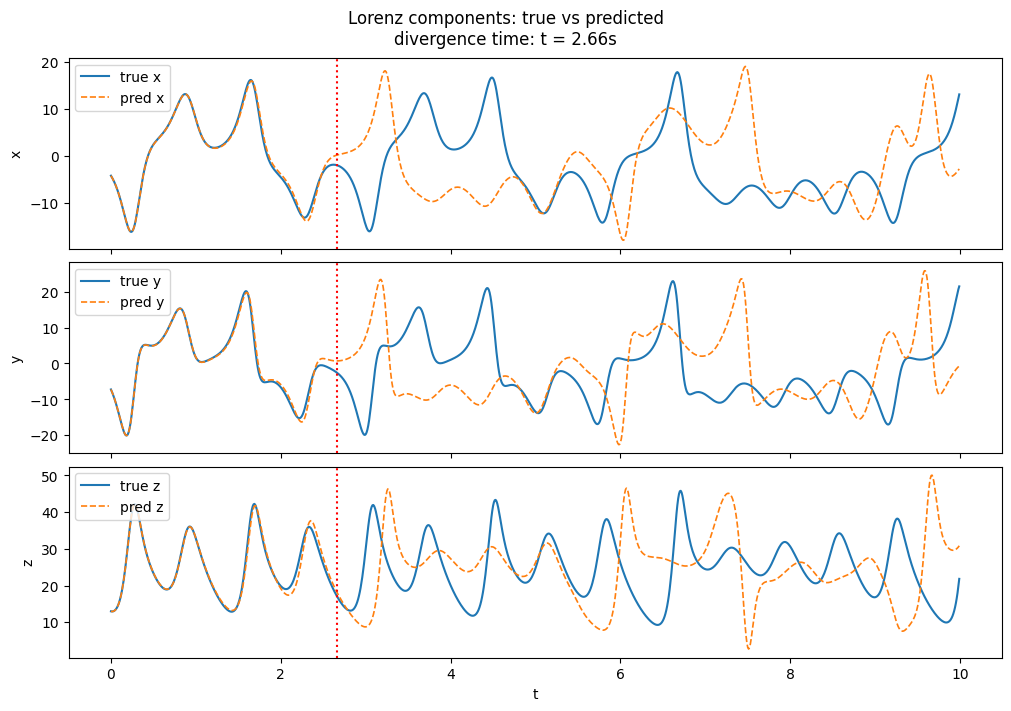

np.float64(2.66)

In [73]:
# ============================================================
# Plot 1: Component-wise comparison
# ============================================================
plot_lorenz_components(Y_pred, Y_true, dt=dt)

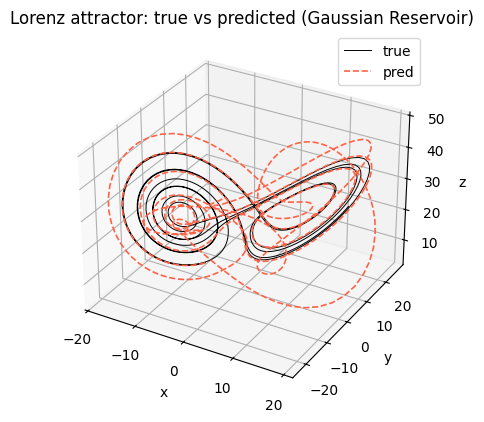

In [54]:
# ============================================================
# Plot 2: 3D attractor (matplotlib)
# ============================================================
plot_lorenz_3d_pred_vs_true(Y_pred, Y_true)

In [55]:
# ============================================================
# Plot 3: Interactive 3D plot (plotly)
# ============================================================
plot_lorenz_3d_interactive(Y_pred, Y_true)